In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Iterator, List, Optional, Tuple, Union
from bayesian_network import BayesNet, Variable
from utils import get_default_bayes_net
from utils import sample_forward, draw_graph, evaluate_bayes_net, compare_bayes_net

# this only works if Problem_1 runs without any errors!
from ipynb.fs.full.Problem_1 import maximum_likelihood_estimate, log_likelihood

# workaround if the ipynb import does not work for you:
#!jupyter nbconvert --to python Problem_1.ipynb
#from Problem_1 import maximum_likelihood_estimate, log_likelihood

# 2. Structure Learning

### Bayesian Information Criterion (BIC)



`bic_score` takes two parameters:
- `data` is a NumPy array of shape `(num_samples, num_variables)`.
- `bayes_net` is a BayesNet object, representing the graph structure for which to compute the BIC-Score. *Assume that the parameters of this bayes_net are set to the maximum likelihood estimate w.r.t. to the data*.

`bic_score` must return one object:
- The BIC-Score, a floating-point number < 0.


*Hint*:
- Use the formula from the lecture slides (slide deck 5b, pp. 48-51)!
- The dimension of a Bayes net is the total number of independent (non-redundant) parameters in the Bayes net.
- Use the natural logarithm for your computations, i.e. `np.log`.
- You can use `Variable.num_values` to fetch the cardinality of a Variable. This is especially helpful for a general solution, where Variables can have more than 2 values. 
- Use your implementation of `log_likelihood` (imported above).

In [3]:
help(log_likelihood)

Help on function log_likelihood in module ipynb.fs.full.Problem_1:

log_likelihood(data: numpy.ndarray, bayes_net: bayesian_network.BayesNet)
    Computes the log-likelihood of a given Bayesian network relative to the data.
    :param data: data to compute the log-likelihood relative to.
    :param bayes_net: Bayesian network model.
    :returns: the log-likelihood of the Bayesian network relative to the data.



In [ ]:
def bic_score(data: np.ndarray, bayes_net: BayesNet) -> float:
    """
    Computes the Bayesian information criterion score assuming a Dirichlet prior over the model parameters.
    :param data:      data to compute the bic score of, a np.ndarray of shape (num_samples, len(bayes_net)).
    :param bayes_net: the model, a BayesNet object.
    :return:          BIC score (float)
    """
    
    assert data.shape[1] == len(bayes_net)
    
    bic = 0
    
    
    # number of samples
    N = data.shape[0]

    # log-likelihood term
    ll = log_likelihood(data, bayes_net)

    # compute model dimension d
    d = 0
    for variable in bayes_net:

        r = variable.num_values        
        parent_ids = variable.parents  

        # product of parent cardinalities
        q = 1
        for p in parent_ids:
            q *= bayes_net[p].num_values  

        d += (r - 1) * q

    # BIC formula
    bic = ll - 0.5 * d * np.log(N)
    
    return bic

In [7]:
import traceback
any_failed = False
try:
    # sanity check
    bayes_net = get_default_bayes_net()
    data = np.array([[0,0,0,0,0], [1,1,1,1,1], [1,1,0,0,0]], dtype=np.int64)
    
    bic = bic_score(data, bayes_net)
    assert isinstance(bic,float), f'`bic_score` should return type float but returns {type(bic)}'
    assert -20 < bic < -10, f'BIC needs to be in ]-20, -10[, but got {bic}'
    
    
except Exception as e:
    print("Error:", e)
    traceback.print_exception(type(e), e, e.__traceback__)
    any_failed = True
finally:
    _ = None
    
assert not any_failed, "See error message above..."

### Complete Search in a Restricted Space

For learning the structure of Bayesian Network, we will focus on complete search in a restricted space.



`complete_search` takes three parameters:
- `data` is a NumPy array of shape `(num_samples, num_variables)`.
- `variable_order` is a list of variable ids (ints) specifying the topological order.
- `score_fun` is the function used to score the candidate graph structure — defaults to `bic_score`. Higher score means better model.
- `max_parents` is an integer value specifying the maximum number of parents a variable can have — defaults to `None`, meaning no restriction
- `variable_cardinality` is the cardinality of the variables (aligned with columns of data)
- `alpha` is a non-negative integer, corresponding to pseudocounts in Laplace smoothing.


`complete_search` must return one object:
- a BayesNet object, which represents the model with the highest score under the given topological order.

*Hints:*
- Get familiar with the algorithm depicted in the lecture slides (slide deck 5b, pp. 54-56)
- Use `score_fun` to compute the score. Do not directly call your implementation of `bic_score`.
- You may use [`itertools.combinations`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to get combinations of parent variables. For the N-th variable in `variable_order`, there are exactly $2^{N-1}$ possible parent sets to be considered (in case `max_parents` is set to `None`, otherwise the number of possible sets may be reduced).
- [`itertools.chain.from_iterable`](https://docs.python.org/3/library/itertools.html#itertools.chain.from_iterable) might become handy for flattening lists of lists of variable indexes.
- Mind that python-objects, such as lists, are passed by reference; updating a value in the list will affect all objects holding the reference! To avoid unintended change, create a copy of the list before you modify it:
```python
best_pdts.copy()
```
- Use a BayesNet only consisting of independent Variables (e.g., no connections) as starting point. Iteratively compare it with other ones and always keep the best.
- Use your implementation of `maximum_likelihood_estimate` (imported above).

In [8]:
help(maximum_likelihood_estimate)

Help on function maximum_likelihood_estimate in module ipynb.fs.full.Problem_1:

maximum_likelihood_estimate(
    data: numpy.ndarray,
    variable_id: int,
    parent_ids: tuple = (),
    variable_cardinality: Optional[Tuple[int]] = (),
    alpha: int = 0
)
    Estimates the conditional probability distribution of a (discrete) variable from data.
    :param data:    data to estimate distribution from
    :param variable_id:  column index corresponding to the variable we estimate the distribution for
    :param parent_ids: column indices of the variables the distribution is conditioned on
    :param variable_cardinality: cardinality of the variables (aligend with data); defaults to binary variables
    :param alpha: smoothing parameter, pseudocounts
    :returns: estimated conditional probability distribution table



In [ ]:
import itertools as it
import copy
def complete_search(data: np.ndarray, variable_order: List[int], score_fun=bic_score, max_parents: Optional[int] = None, variable_cardinality: Union[Tuple[int], None] = tuple(), alpha: float = 0.0) -> BayesNet:
    """
    Learns the structure and parameters of a Bayesian net using score-based search over a 
        search space restricted by a pre-determined variable order.
    :param data: the training data, a NumPy array of shape (num_samples, len(bayes_net)).
    :param variable_order: a list containing the topological order of the variables (list of indices).
    :param score_fun: is the function used to score the candidate graph structure — defaults to `bic_score`. 
    :param max_parents: an integer value specifying the maximum number of parents a variable can have — defaults to `None` (no restriction).
    :param variable_cardinality: cardinality of the variables (aligend with data) — defaults to binary variables if `None` or empty tuple .
    :param alpha: smoothing parameter, pseudocounts
    :return: a BayesNet object, which represents the model with the highest BIC-Score under the given topological order.
    """
    assert len(variable_order) == data.shape[1]
    assert max_parents is None or max_parents >= 0
    
    best_pdts = [maximum_likelihood_estimate(data, variable_id, variable_cardinality=variable_cardinality, alpha=alpha) for variable_id in variable_order]
    best_indices = [(variable_id,) for variable_id in variable_order]
    best_model = BayesNet(*zip(best_pdts, best_indices))
    
    
    if variable_cardinality is None or len(variable_cardinality) == 0:
        variable_cardinality = (2,) * data.shape[1]

    # iterate through variables in the given topological order
    for i, var in enumerate(variable_order):

        # possible parents = earlier variables in topological order
        possible_parents = variable_order[:i]

        # all subsets of possible parents
        if max_parents is None:
            parent_sets = it.chain.from_iterable(
                it.combinations(possible_parents, k) for k in range(len(possible_parents) + 1)
            )
        else:
            parent_sets = it.chain.from_iterable(
                it.combinations(possible_parents, k) for k in range(min(max_parents, len(possible_parents)) + 1)
            )

        best_score = -np.inf
        best_pdt = None
        best_parent_set = None

        # try each parent set
        for parents in parent_sets:

            # estimate CPT for this variable given parents
            pdt = maximum_likelihood_estimate(
                data,
                variable_id=var,
                parent_ids=parents,
                variable_cardinality=variable_cardinality,
                alpha=alpha
            )

            # build temporary PDTS & indices
            tmp_pdts = best_pdts.copy()
            tmp_indices = best_indices.copy()

            # update pdt + structure for this variable
            tmp_pdts[i] = pdt
            tmp_indices[i] = (var,) + parents

            # build temporary model and score it
            tmp_model = BayesNet(*zip(tmp_pdts, tmp_indices))
            score = score_fun(data, tmp_model)

            if score > best_score:
                best_score = score
                best_pdt = pdt
                best_parent_set = parents

        best_pdts[i] = best_pdt
        best_indices[i] = (var,) + best_parent_set

    best_model = BayesNet(*zip(best_pdts, best_indices))
    return best_model

In [10]:
import traceback
any_failed = False
try:
    data = np.array(np.indices((2,) * 5).reshape(5, -1).T, dtype=np.int64)
    bayes_net = complete_search(data, [0,1,2,3,4])
    assert len(bayes_net) == 5, f'\nBayesNet should contain all 5 Variables.' \
                                f'\nIt only contained {len(bayes_net)} being {set(it.chain(*bayes_net.indices))}.'\
                                f'\nMissing: {set(range(5))-set(it.chain(*bayes_net.indices))}.'\
                                f'\nMost likely there is an error in how you construct your `new` BayesNet during learning.'
    
    assert np.all(np.isclose(bayes_net.pdts[0], np.array([0.5, 0.5]), atol=0.1))
    assert bayes_net.indices[1] == (1,), 'Algorithm should favor no parents.'
    
    bayes_net = complete_search(data, [0,1,2,3,4], score_fun=lambda d, n: 0.0)
    assert bayes_net.indices[1] == (1,), 'it seems complete_search() uses bic_score() instead of score_fun()'
    
    data = np.random.choice([0,1], (500,5)).astype(np.int64)
    max_parents = 2
    bayes_net = complete_search(data, [0,1,2,3,4], score_fun=log_likelihood, max_parents=max_parents)
    assert max([len(var.parents) for var in bayes_net]) == max_parents, 'it seems that the parameter `max_parents` is not correctly used'
    
except Exception as e:
    print("Error:", e)
    traceback.print_exception(type(e), e, e.__traceback__)
    any_failed = True
finally:
    _ = None
assert not any_failed, "See error message above..."

### Structure Learning on the Strokes Dataset

---


Equipped with the freshly acquired knowledge about structure learning, you revisit the probabilistic medical world from the previous notebook, which comprises the following random variables:

 - A ... Alcoholism
 - H ... High Blood Pressure
 - S ... Stroke
 - C ... Confusion
 - V ... Vertigo

This time, you aim to compensate for your lack of domain knowledge by taking a more data-driven approach, letting the data guide you in finding the correct structure.

Below is the true underlying Bayesian model (structure and parameters) used to generate the training and test data for you.

All variables in this example are Boolean (false = 0, true = 1).



The conditional probability tables are given as follows:

We generate three datasets of varying sizes (1,000, 10,000, and 20,000 data points) along with a test set (10,000 data points). These datasets are stored in the variables *train_small*, *train_medium*, *train_big*, *test*.

Now, it is your turn to (re-)discover the true underlying Bayesian network that generated the data.

In [11]:
_A_, _H_, _S_, _C_, _V_ = 0, 1, 2, 3, 4


_A_, _H_, _S_, _C_, _V_ = 0, 1, 2, 3, 4
A = np.array([0.01, 0.99])
H_A = np.array([[0.9, 0.8], [0.1, 0.2]])
S_H = np.array([[0.9, 0.85], [0.1, 0.15]])
C_AS = np.array([[[0.8, 0.7], [0.85, 0.45]], [[0.2, 0.3], [0.15, 0.55]]])
V_S = np.array([[0.1, 0.2], [0.9, 0.8]])

# this bayes net represents the true underlying full joint distribution in the medical world 
true_bayes_net = BayesNet(
    (A, (_A_,)),
    (H_A, (_H_,_A_)),
    (S_H, (_S_,_H_)),
    (C_AS, (_C_,_A_,_S_)),
    (V_S, (_V_,_S_))
)
np.random.seed(0)
train_small = sample_forward(true_bayes_net, 1_000)
train_medium = sample_forward(true_bayes_net, 5_000)
train_big = sample_forward(true_bayes_net, 50_000)
test = sample_forward(true_bayes_net, 10_000)

### Experiments

Although you have a hard time determining the dependencies among the random variables directly, you have some idea which of the variables might be dependent on each other and, therefore, you decide to use **Complete Search in Restricted Space** to find the best model. You come up with several *variable orders* to restrict the search space strongly and consider the following configurations:




*Hints:*
- You can use `log_likelihood` as a scoring function by overwriting the default choice for the named parameter `score_fun` of `complete_search`, e.g.,
```python
complete_search(data, order, score_fun=log_likelihood)
```
- Use Lapace smoothing ($\alpha = 0.01$) to avoid numerical issues.

In [12]:
help(draw_graph)
help(evaluate_bayes_net)

Help on function draw_graph in module utils:

draw_graph(
    bayes_net: bayesian_network.BayesNet,
    node_names: list = None,
    pos: dict = None
) -> None
    Draws the Bayesian net.
    :param bayes_net: a BayesNet object representing the graph structure to draw.
    :param node_names: Display Name of the variables.
                       Defaults to values for the stroke-example.
    :param pos: position of the variables (dict: key=variable_name, value: list: x, y).
                Defaults to values for the stroke-example.

Help on function evaluate_bayes_net in module utils:

evaluate_bayes_net(
    bayes_net: bayesian_network.BayesNet,
    train_set: numpy.ndarray,
    test_set: numpy.ndarray,
    log_likelihood
) -> tuple
    Computes the mean likelihood of the Bayesian network under the training and test data
    :param bayes_net: a BayesNet object, representing the model.
    :param train_set: the training set, a NumPy array of shape (num_samples, len(bayes_net)).
    :par


=== Data set: small (1000 samples) ===
  Building ordered (BIC) model...


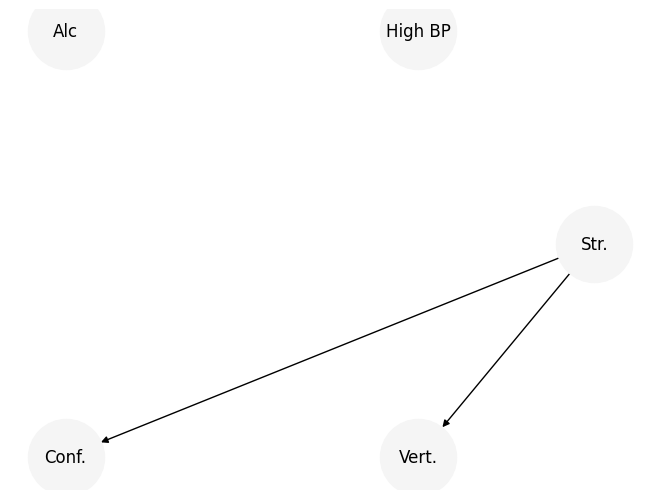

    ordered: train LL = -1.670, test LL = -1.684
  Building reverse (BIC) model...


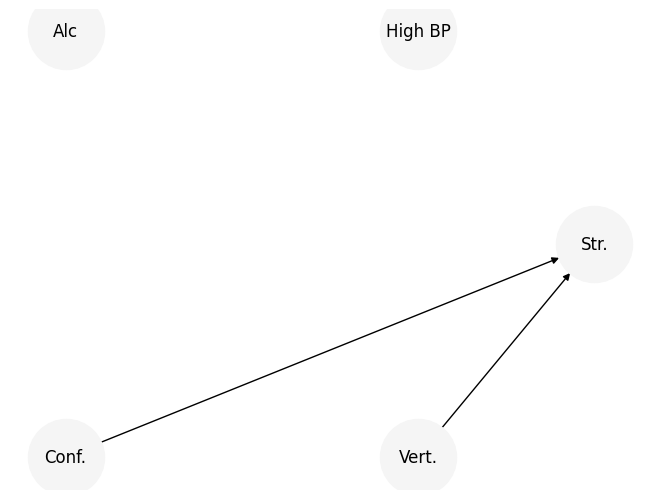

    reverse: train LL = -1.671, test LL = -1.684
  Building random (BIC) model...


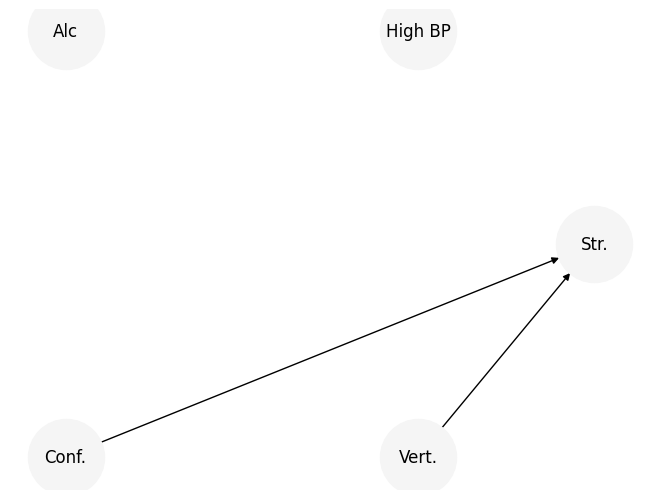

    random: train LL = -1.671, test LL = -1.684
  Building ordered (log-likelihood) model...


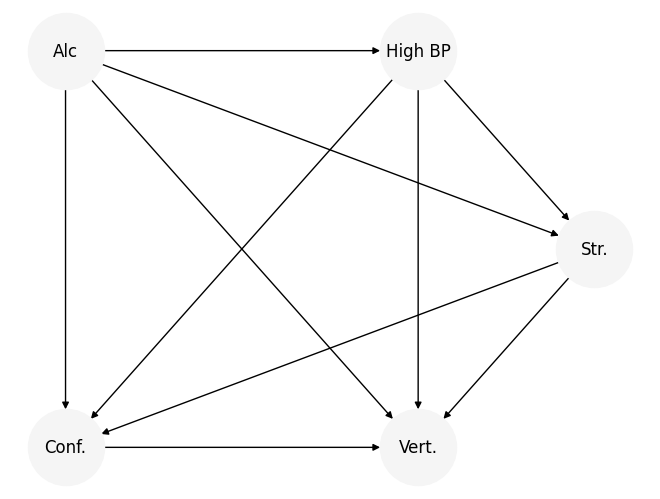

    log-likelihood: train LL = -1.661, test LL = -1.693

=== Data set: medium (5000 samples) ===
  Building ordered (BIC) model...


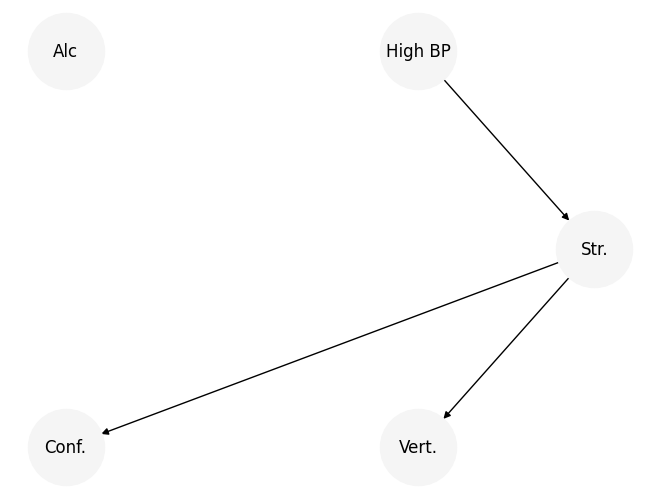

    ordered: train LL = -1.706, test LL = -1.683
  Building reverse (BIC) model...


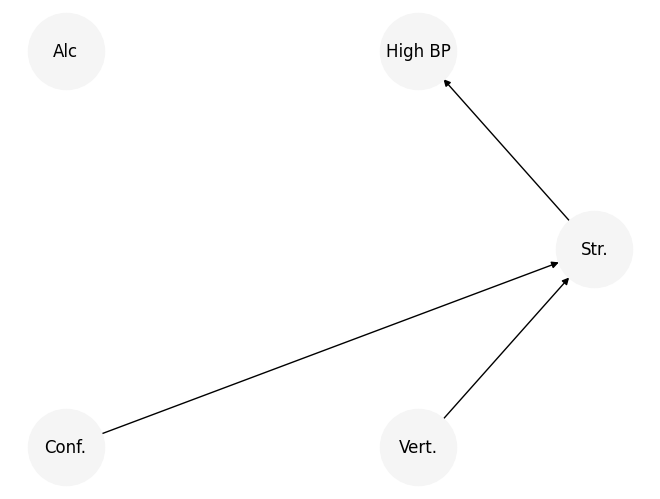

    reverse: train LL = -1.705, test LL = -1.683
  Building random (BIC) model...


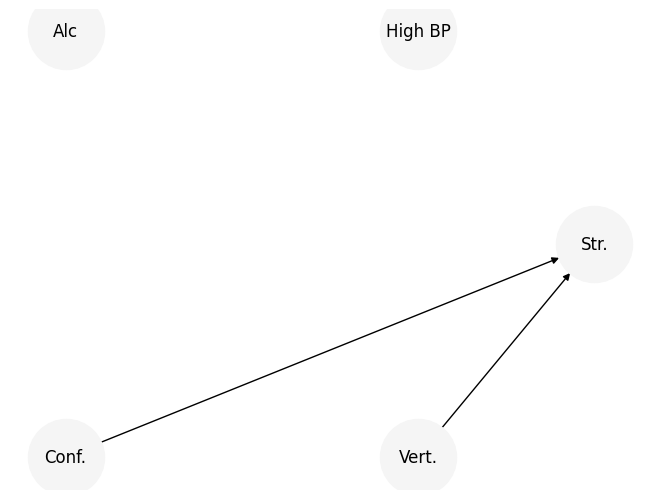

    random: train LL = -1.707, test LL = -1.684
  Building ordered (log-likelihood) model...


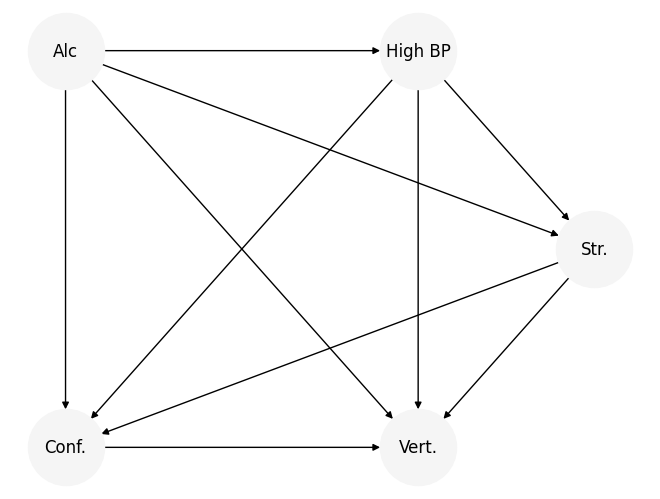

    log-likelihood: train LL = -1.702, test LL = -1.685

=== Data set: big (50000 samples) ===
  Building ordered (BIC) model...


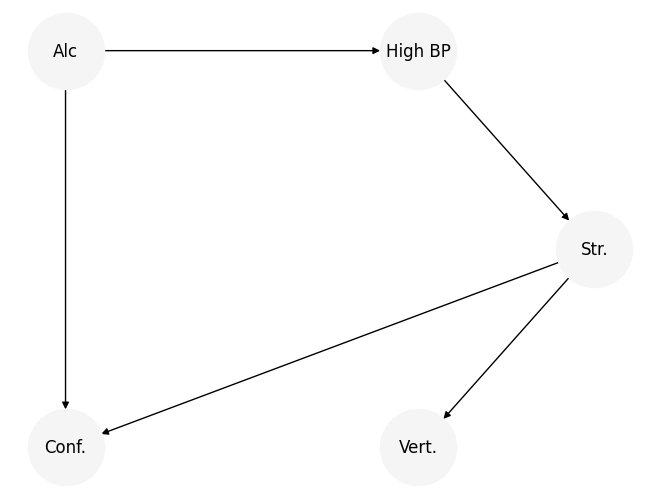

    ordered: train LL = -1.695, test LL = -1.680
  Building reverse (BIC) model...


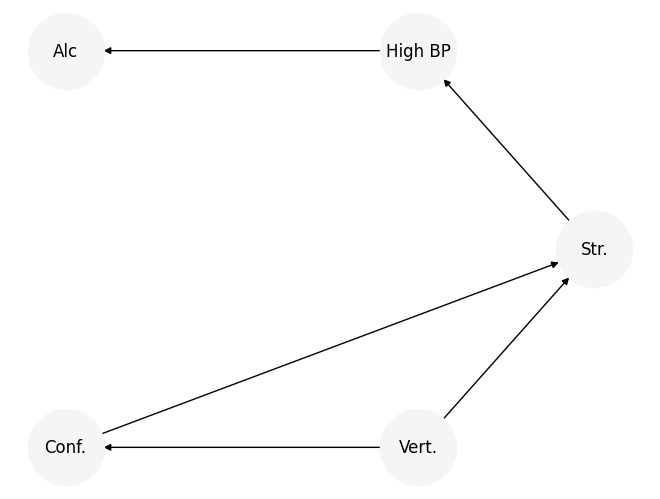

    reverse: train LL = -1.696, test LL = -1.680
  Building random (BIC) model...


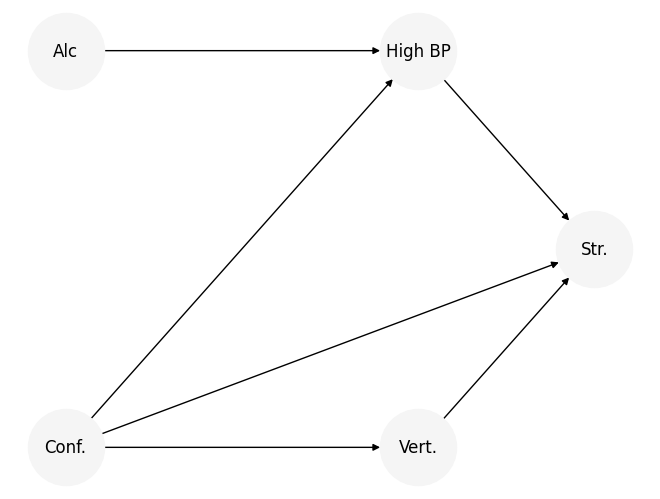

    random: train LL = -1.696, test LL = -1.680
  Building ordered (log-likelihood) model...


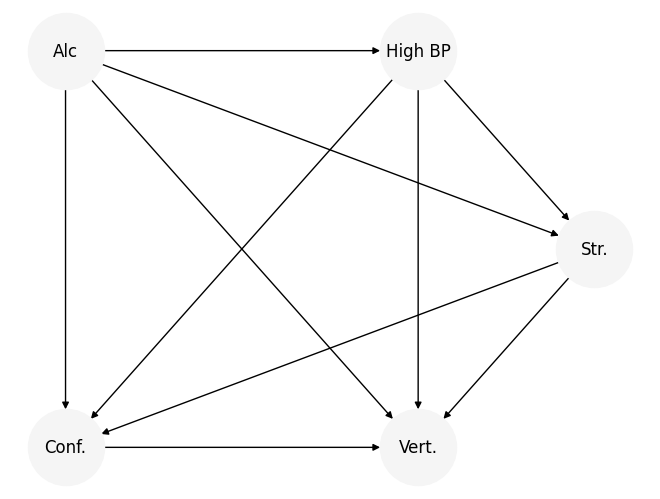

    log-likelihood: train LL = -1.695, test LL = -1.680


In [ ]:
cs_models = {}
for data_set_size in ['small', 'medium', 'big']:
    cs_models[data_set_size] = {
            'ordered': None, # _A_, _H_, _S_, _C_, _V_; bic_score
            'reverse': None, # _V_, _C_, _S_, _H_, _A_; bic_score
            'random': None, # _C_, _A_, _H_, _V_, _S_; bic_score
            'log-likelihood': None, # _A_, _H_, _S_, _C_, _V_; log_likelihood
        }


# variable orders
order_ordered = [_A_, _H_, _S_, _C_, _V_]           
order_reverse = [_V_, _C_, _S_, _H_, _A_]           
order_random  = [_C_, _A_, _H_, _V_, _S_]            
order_ll      = [_A_, _H_, _S_, _C_, _V_]            

alpha = 0.01
variable_cardinality = (2,) * 5

datasets = {
    'small': train_small,
    'medium': train_medium,
    'big': train_big
}

for size_name, dataset in datasets.items():
    print(f"\n=== Data set: {size_name} ({dataset.shape[0]} samples) ===")

    # 1) ordered (BIC)
    print("  Building ordered (BIC) model...")
    bn_ord = complete_search(dataset, order_ordered, score_fun=bic_score,
                             max_parents=None, variable_cardinality=variable_cardinality, alpha=alpha)
    cs_models[size_name]['ordered'] = bn_ord
    draw_graph(bn_ord)
    tr_ll, te_ll = evaluate_bayes_net(bn_ord, dataset, test, log_likelihood)
    print(f"    ordered: train LL = {tr_ll:.3f}, test LL = {te_ll:.3f}")

    # 2) reverse (BIC)
    print("  Building reverse (BIC) model...")
    bn_rev = complete_search(dataset, order_reverse, score_fun=bic_score,
                             max_parents=None, variable_cardinality=variable_cardinality, alpha=alpha)
    cs_models[size_name]['reverse'] = bn_rev
    draw_graph(bn_rev)
    tr_ll, te_ll = evaluate_bayes_net(bn_rev, dataset, test, log_likelihood)
    print(f"    reverse: train LL = {tr_ll:.3f}, test LL = {te_ll:.3f}")

    # 3) random (BIC)
    print("  Building random (BIC) model...")
    bn_rnd = complete_search(dataset, order_random, score_fun=bic_score,
                             max_parents=None, variable_cardinality=variable_cardinality, alpha=alpha)
    cs_models[size_name]['random'] = bn_rnd
    draw_graph(bn_rnd)
    tr_ll, te_ll = evaluate_bayes_net(bn_rnd, dataset, test, log_likelihood)
    print(f"    random: train LL = {tr_ll:.3f}, test LL = {te_ll:.3f}")

    # 4) ordered but score by log-likelihood directly
    print("  Building ordered (log-likelihood) model...")
    bn_ll = complete_search(dataset, order_ll, score_fun=log_likelihood,
                             max_parents=None, variable_cardinality=variable_cardinality, alpha=alpha)
    cs_models[size_name]['log-likelihood'] = bn_ll
    draw_graph(bn_ll)
    tr_ll, te_ll = evaluate_bayes_net(bn_ll, dataset, test, log_likelihood)
    print(f"    log-likelihood: train LL = {tr_ll:.3f}, test LL = {te_ll:.3f}")

In [14]:
for data_set_id in ['small', 'medium', 'big']:
    for combination_id in ['ordered', 'reverse', 'random', 'log-likelihood']:
        assert type(cs_models[data_set_id][combination_id]) is BayesNet
        

### Interpretation

In the following, we will compare all learned Bayesian Network structures (stored in variables `cs_models`) w.r.t. their log-likelihoods on train and test datasets.

The first type of plots visualize the training set size's influence on the log-likelihood relative to the test data.

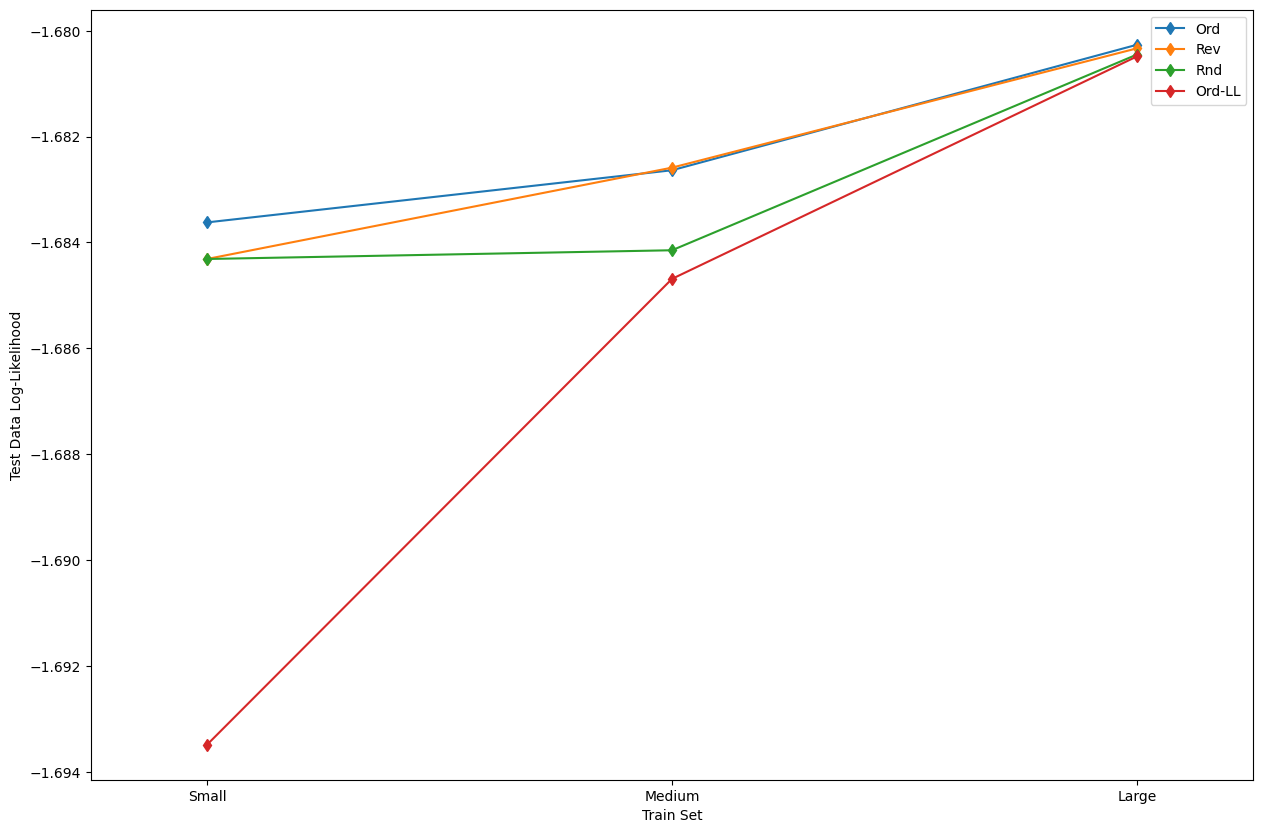

In [15]:
from utils import plot_compare_orders, compare_train_size

compare_train_size(cs_models, [train_small, train_medium, train_big], test, cs=True, log_likelihood=log_likelihood)

The second type of plots compare all configurations' log-likelihood relative to the training and test data for each dataset size.

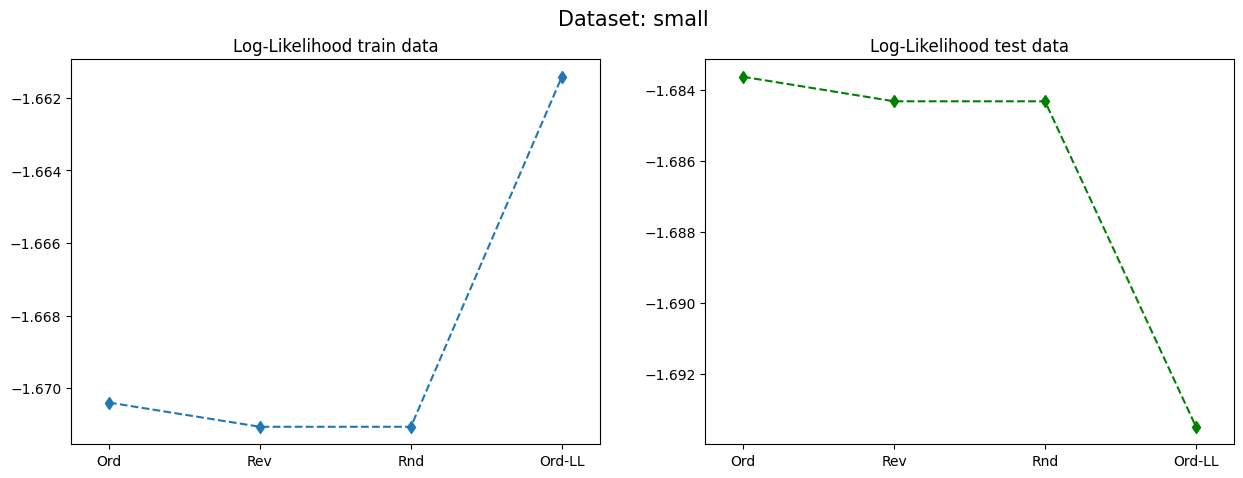

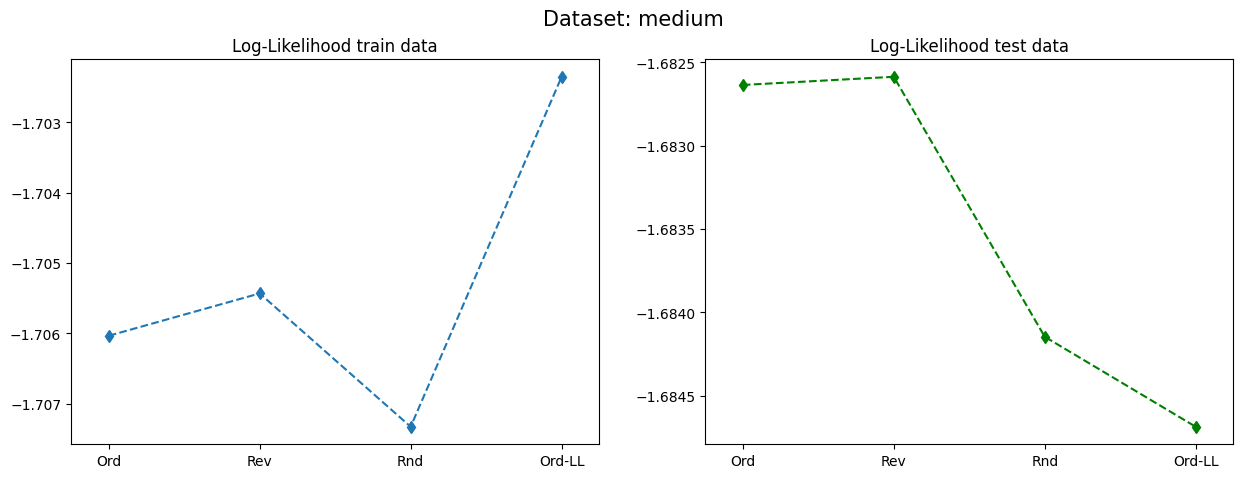

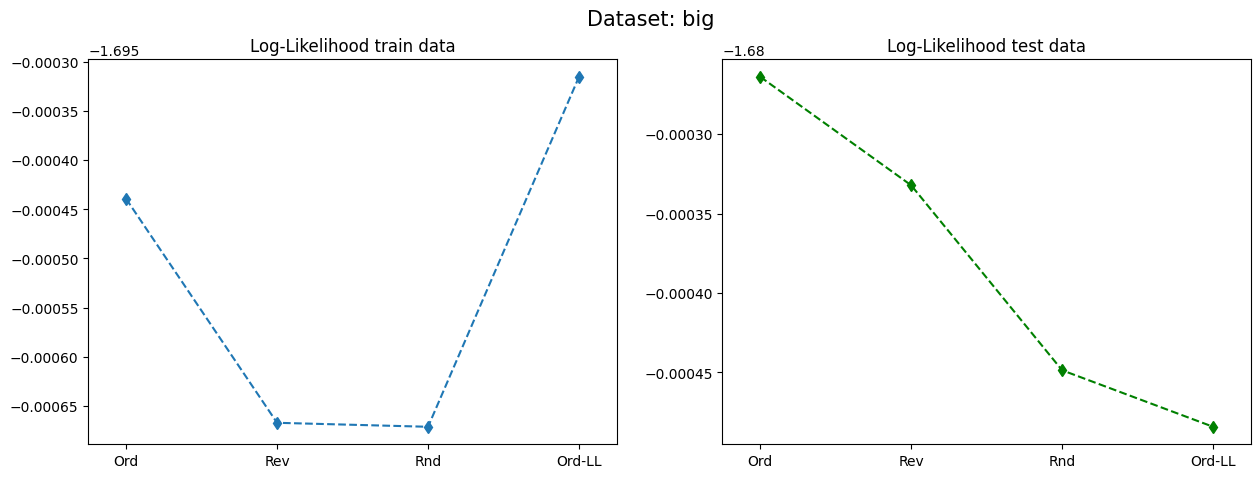

In [16]:
plot_compare_orders(cs_models, [train_small, train_medium, train_big], test, log_likelihood=log_likelihood)

**Question 2.3.2.1:** Looking at the plots and the test likelihood scores for the medium dataset in isolation: (1) In this specific situation, which combination of variable ordering and scoring function is preferable?

### Observation

In the experiment, the ordered configuration using BIC provided a strong balance between model fit and complexity, while direct log-likelihood scoring was more prone to favoring complex structures.

### Observation: Restricted vs. Full Search

A restricted search can return a good but suboptimal structure. Starting a heuristic search from that structure does not guarantee recovery of the global optimum because heuristic search can remain in a local optimum.

In [18]:
result = False  # store True or False into this variable



In [19]:
assert result is not None
assert result in [True, False]

### Observation: Score Decomposition

For complete search under a fixed variable order, the best parent set for a variable can be evaluated locally because the Bayesian Network score decomposes over variables. Later-variable parent choices do not change the local score of an earlier variable.

In [20]:
result = False  # store True or False into this variable



In [21]:
assert result is not None
assert result in [True, False]